In [3]:
import oncophylo as op
import numpy as np
import pandas as pd
import anndata as ad
import os, sys
import matplotlib.pyplot as plt

In [4]:
path = os.path.join(os.getcwd(), "data", "AML")

In [5]:
sample1 = "AML-97-001"
sample2 = "AML-97-002"
sample3 = "AML-97-003"
sample4 = "AML-97-004"
sample5 = "AML-97-005"
sample6 = "AML-97-006"

In [6]:
sample1_variants_df = pd.read_csv(os.path.join(path, f"{sample1}_variants.csv"), header=0, index_col=0)
sample1_regions_df = pd.read_csv(os.path.join(path, f"{sample1}_regions.csv"), header=None, index_col=0)

sample2_variants_df = pd.read_csv(os.path.join(path, f"{sample2}_variants.csv"), header=0, index_col=0)
sample2_regions_df = pd.read_csv(os.path.join(path, f"{sample2}_regions.csv"), header=None, index_col=0)

sample3_variants_df = pd.read_csv(os.path.join(path, f"{sample3}_variants.csv"), header=0, index_col=0)
sample3_regions_df = pd.read_csv(os.path.join(path, f"{sample3}_regions.csv"), header=None, index_col=0)

sample4_variants_df = pd.read_csv(os.path.join(path, f"{sample4}_variants.csv"), header=0, index_col=0)
sample4_regions_df = pd.read_csv(os.path.join(path, f"{sample4}_regions.csv"), header=None, index_col=0)

sample5_variants_df = pd.read_csv(os.path.join(path, f"{sample5}_variants.csv"), header=0, index_col=0)
sample5_regions_df = pd.read_csv(os.path.join(path, f"{sample5}_regions.csv"), header=None, index_col=0)

sample6_variants_df = pd.read_csv(os.path.join(path, f"{sample6}_variants.csv"), header=0, index_col=0)
sample6_regions_df = pd.read_csv(os.path.join(path, f"{sample6}_regions.csv"), header=None, index_col=0)

data = [(sample1_variants_df, sample1_regions_df), 
        (sample6_variants_df, sample6_regions_df)]

# data is missing from samples 2-5

In [7]:
character_matrix, variant_reads_df, total_reads_df, meta_df, regions_df, cell_samples = op.ul.preprocess_longitudinal(data)

/Users/ethank/oncophylo/oncophylo/ul/_longitudinal.py:115: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  merged_meta_df = pd.merge(merged_meta_df, meta_df, how="outer").reset_index(drop=True)


In [ ]:
sol_COMPASS = op.tl.solver.COMPASS(character_matrix, variant_reads_df, total_reads_df, regions_df, meta_df, remove_temp_dir=False)

In [ ]:
op.pl.show_tree(sol_COMPASS[op.ul.DATA.MUTATION_TREE])

In [8]:
sol_LoPhy = op.tl.solver.LoPhy(character_matrix.replace(2,1).replace(3,-1), 
                                         variant_reads_df, 
                                         total_reads_df,                        
                                         regions_df, 
                                         meta_df,
                                         cell_samples=cell_samples,
                                         remove_temp_dir=False,
                                         seed=0)

In [9]:
T = sol_LoPhy[op.ul.DATA.MUTATION_TREE].copy()

In [10]:
sol_LoPhy[op.ul.EVAL_KEYS.RUNTIME]

205.11728216696065

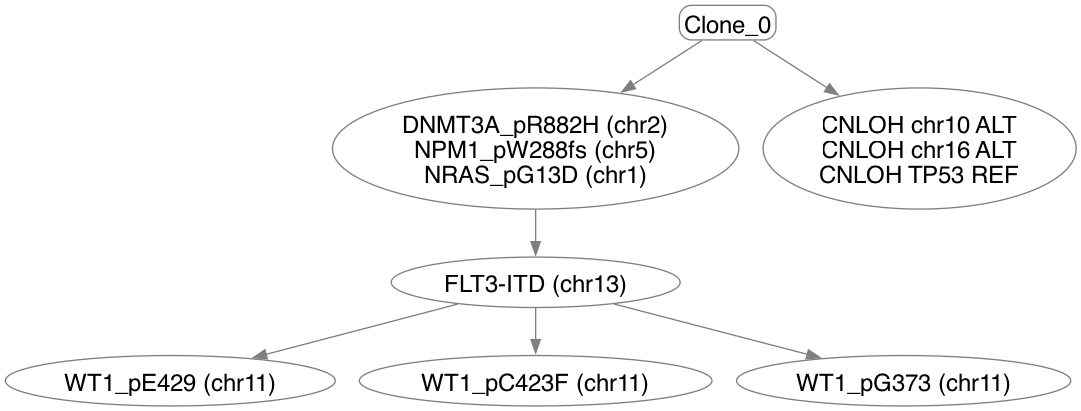

In [11]:
op.pl.show_tree(T)